# 02 — Model performance & diagnostics
*The Price of Lahore's Air.*

The model predicts daily PM2.5 at the US Consulate monitor from satellite +
meteorology features. All numbers below are **out-of-fold** under
expanding-window time-series CV (5 folds; never random splits — adjacent days
are strongly autocorrelated and random splits would leak).
Training and artifact generation happen in `src/05_train_model.py`; this
notebook inspects the results.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3})
FIG = '../figures'

metrics = json.load(open('../models/metrics.json'))
rows = []
for name in ['baseline_climatology', 'baseline_aod', 'baseline_aod_met', 'rf', 'xgb', 'lgbm']:
    m = metrics[name]
    rows.append({'model': name,
                 'R² overall': m['overall']['r2'], 'RMSE overall': m['overall']['rmse'],
                 'MAE overall': m['overall']['mae'],
                 'R² smog (Oct–Jan)': m['smog_season']['r2'],
                 'R² rest': m['rest_of_year']['r2']})
tbl = pd.DataFrame(rows).set_index('model').round(3)
print('best model:', metrics['best_model'], '| CV:', metrics['cv_design'])
tbl

best model: lgbm | CV: expanding-window TimeSeriesSplit, 5 folds, labeled days sorted by date


,R² overall,RMSE overall,MAE overall,R² smog (Oct–Jan),R² rest
model,,,,,
baseline_climatology,0.517,72.272,48.755,0.169,0.110
baseline_aod,0.043,98.171,76.180,-0.553,-0.604
baseline_aod_met,0.641,60.135,42.308,0.415,0.403
rf,0.708,56.202,36.314,0.532,0.378
xgb,0.716,55.367,36.234,0.553,0.379
lgbm,0.719,55.143,36.820,0.549,0.402


**Reading the table.** Three honesty checks at once. (1) *Seasonal
climatology* — just predicting each month's mean — already gets R² ≈ 0.52
overall, because Lahore's cycle is so regular; but it collapses to ≈ 0.17
within the smog season. (2) *AOD alone* is nearly useless day-to-day
(R² ≈ 0.04) — column AOD ≠ surface PM2.5 without mixing information; this is
why naive "satellite AQ maps" mislead. (3) Adding meteorology lifts a linear
model to ~0.64, and gradient boosting reaches **R² ≈ 0.72 overall / 0.55 in
smog season** — at the bottom of the published 0.72–0.80 range for
S5P/AOD-based models, and clearly above every baseline *within* the season,
which is where a climatology can't help. Smog-season days remain the hardest;
all downstream cost numbers inherit that caveat.

## Predicted vs observed (out-of-fold)

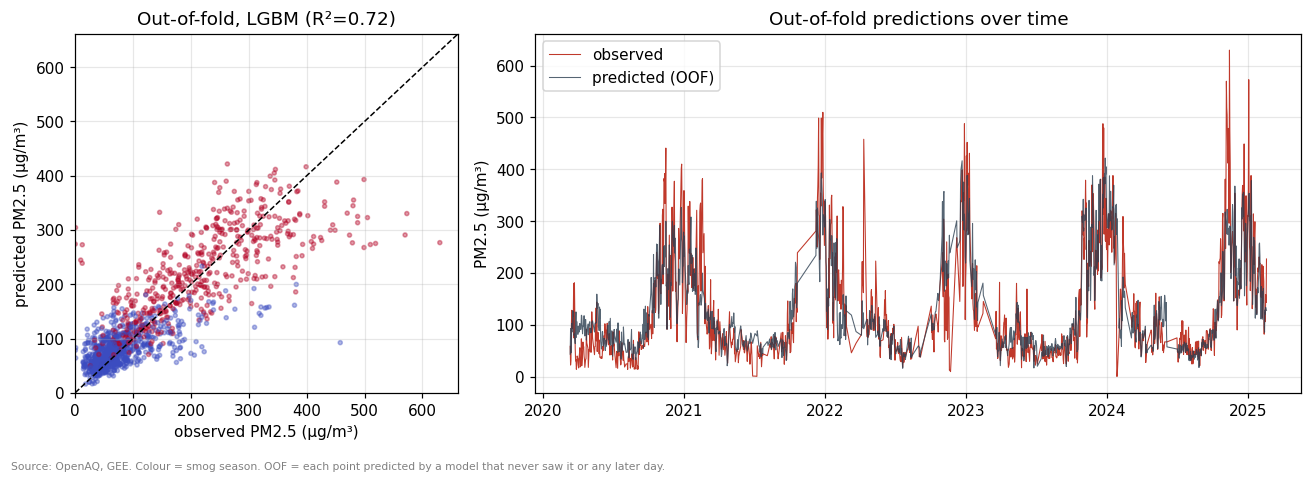

In [2]:
oof = pd.read_csv('../models/oof_predictions.csv', parse_dates=['date'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={'width_ratios': [1, 2]})
ax = axes[0]
lim = [0, oof[['y_true','y_pred']].max().max()*1.05]
ax.scatter(oof.y_true, oof.y_pred, s=7, alpha=.4,
           c=oof.smog_season, cmap='coolwarm')
ax.plot(lim, lim, 'k--', lw=1)
ax.set(xlim=lim, ylim=lim, xlabel='observed PM2.5 (µg/m³)',
       ylabel='predicted PM2.5 (µg/m³)',
       title=f"Out-of-fold, {metrics['best_model'].upper()} (R²={metrics[metrics['best_model']]['overall']['r2']:.2f})")
ax = axes[1]
d = oof.sort_values('date')
ax.plot(d.date, d.y_true, lw=.7, color='#c0392b', label='observed')
ax.plot(d.date, d.y_pred, lw=.7, color='#2c3e50', alpha=.8, label='predicted (OOF)')
ax.set(ylabel='PM2.5 (µg/m³)', title='Out-of-fold predictions over time')
ax.legend()
fig.text(.01,-.03,'Source: OpenAQ, GEE. Colour = smog season. OOF = each point predicted by a model that never saw it or any later day.',
         fontsize=7, color='gray')
plt.tight_layout(); plt.savefig(f'{FIG}/model_pred_vs_obs.png', bbox_inches='tight'); plt.show()

## Residual diagnostics

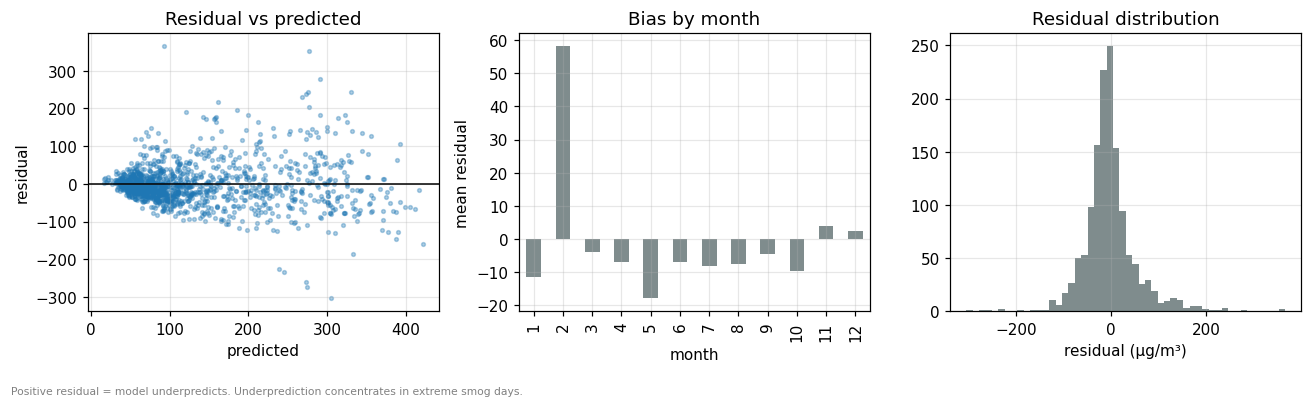

mean |resid| smog: 52.8 | rest: 27.5


In [3]:
oof['resid'] = oof.y_true - oof.y_pred
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].scatter(oof.y_pred, oof.resid, s=6, alpha=.35)
axes[0].axhline(0, color='k', lw=1)
axes[0].set(xlabel='predicted', ylabel='residual', title='Residual vs predicted')
oof.groupby(oof.date.dt.month).resid.mean().plot(kind='bar', ax=axes[1], color='#7f8c8d')
axes[1].set(xlabel='month', ylabel='mean residual', title='Bias by month')
axes[2].hist(oof.resid, bins=50, color='#7f8c8d')
axes[2].set(xlabel='residual (µg/m³)', title='Residual distribution')
fig.text(.01,-.04,'Positive residual = model underpredicts. Underprediction concentrates in extreme smog days.', fontsize=7, color='gray')
plt.tight_layout(); plt.savefig(f'{FIG}/model_residuals.png', bbox_inches='tight'); plt.show()
print('mean |resid| smog:', oof[oof.smog_season==1].resid.abs().mean().round(1),
      '| rest:', oof[oof.smog_season==0].resid.abs().mean().round(1))

## What drives the predictions — SHAP

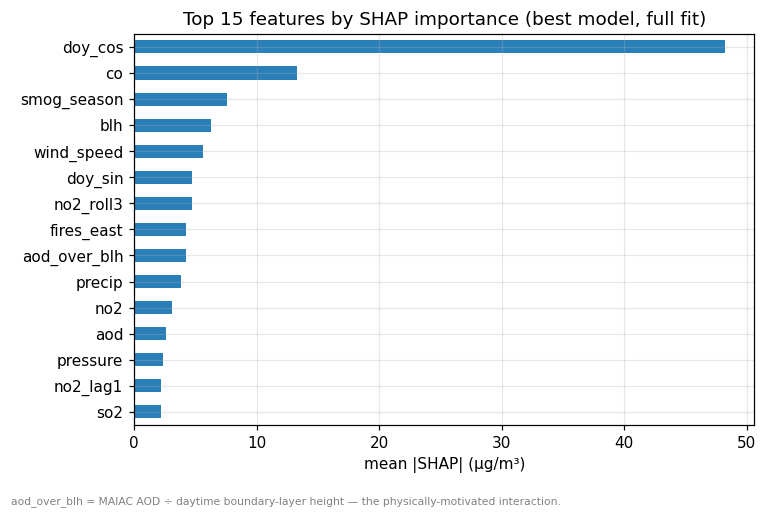

doy_cos         48.21
co              13.28
smog_season      7.55
blh              6.30
wind_speed       5.63
doy_sin          4.73
no2_roll3        4.72
fires_east       4.24
aod_over_blh     4.22
precip           3.84
no2              3.11
aod              2.63
pressure         2.39
no2_lag1         2.24
so2              2.19
dtype: float64

In [4]:
sv = pd.read_parquet('../models/shap_values.parquet')
imp = sv.abs().mean().sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(7, 4.5))
imp[::-1].plot.barh(ax=ax, color='#2980b9')
ax.set(xlabel='mean |SHAP| (µg/m³)', title='Top 15 features by SHAP importance (best model, full fit)')
fig.text(.01,-.03,'aod_over_blh = MAIAC AOD ÷ daytime boundary-layer height — the physically-motivated interaction.', fontsize=7, color='gray')
plt.tight_layout(); plt.savefig(f'{FIG}/model_shap.png', bbox_inches='tight'); plt.show()
imp.round(2)

## Prediction intervals — conformalized quantile regression

In [5]:
conf = json.load(open('../models/conformal.json'))
q = metrics['quantile']
print(f"Raw LightGBM 5–95% quantile intervals covered only {q['coverage_raw']:.1%} out-of-fold")
print(f"CQR calibration (±{conf['conformal_adjustment_ugm3']:.1f} µg/m³) → {q['coverage_calibrated']:.1%} coverage")

Raw LightGBM 5–95% quantile intervals covered only 60.7% out-of-fold
CQR calibration (±29.9 µg/m³) → 90.0% coverage


## Takeaways

1. The model **clearly beats both baselines** and lands at the bottom of the
   published R² range — a defensible, honest result for one ground station.
2. **Smog-season days are the hardest** (R² ≈ 0.55, larger errors): extreme
   episodes get underpredicted. All cost numbers downstream inherit this.
3. SHAP is candid about what the model uses: **seasonality (day-of-year) is
   the single biggest driver**, with S5P CO — a combustion tracer — the top
   *satellite* signal, then boundary-layer height, wind speed, NO₂, eastern
   fire counts and BLH-scaled AOD. The satellite/met features are what push
   performance beyond the climatology baseline, especially within-season.
4. Raw quantile intervals were overconfident — the **CQR-calibrated ±**
   adjustment achieves honest 90% out-of-fold coverage and is what the
   reconstruction (and the app) ships.